In [15]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as scip
import sklearn as sk
from sklearn.neighbors import KernelDensity
from astroML import stats as astroMLstats

THE IRREDUCIBLE MASS OF BH

Binsize with Freedman-Diaconis rule: 0.016744309422188408
Binsize with Scott rule: 0.02251571774425402


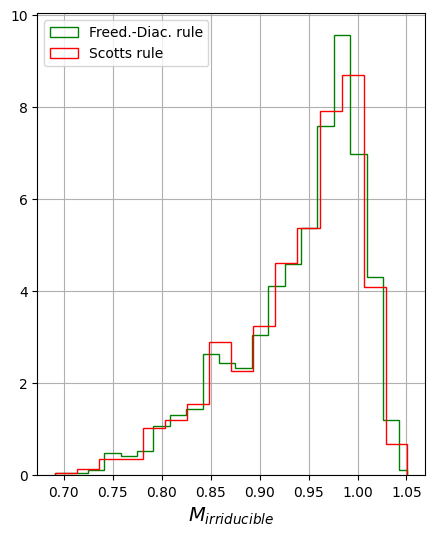

In [34]:
mu, sigma = 1, 0.02
N = 1000

spin_distribution = np.random.uniform(0, 1, N)
mass_distribution = np.random.normal(mu, sigma, N)
f_spin = (((1 + (1-spin_distribution**2)**(1/2)))/2)**(1/2)

M_irr = mass_distribution * f_spin


# Bin size with the "Freedman-Diaconis rule" and "Scott's rule"
sigmaG = astroMLstats.sigmaG(M_irr) #sigmaG compute as $$\sigma_G = 0.7413 \times (q_{75} - q_{25})$$
binsizeFD = 2.7*sigmaG/(N**(1/3))
print(f'Binsize with Freedman-Diaconis rule: {binsizeFD}')
binsFD = np.append(np.arange(start=M_irr.min(), stop=M_irr.max(), step=binsizeFD) , M_irr.max()) 

sigmaS = np.std(M_irr)
binsizeS = 3.5*sigmaS/(N**(1/3))
print(f'Binsize with Scott rule: {binsizeS}')
binsS = np.append(np.arange(start=M_irr.min(), stop=M_irr.max(), step=binsizeS) , M_irr.max()) 



plt.figure(figsize=(5, 6))
plt.hist(M_irr, bins=binsFD, density=True, histtype="step", label='Freed.-Diac. rule', color='green')
plt.hist(M_irr, bins=binsS, density=True, histtype="step", label='Scotts rule', color='red')

plt.xlabel('$M_{irriducible}$', fontsize=14)
plt.legend(loc='upper left')
plt.grid()
plt.show()

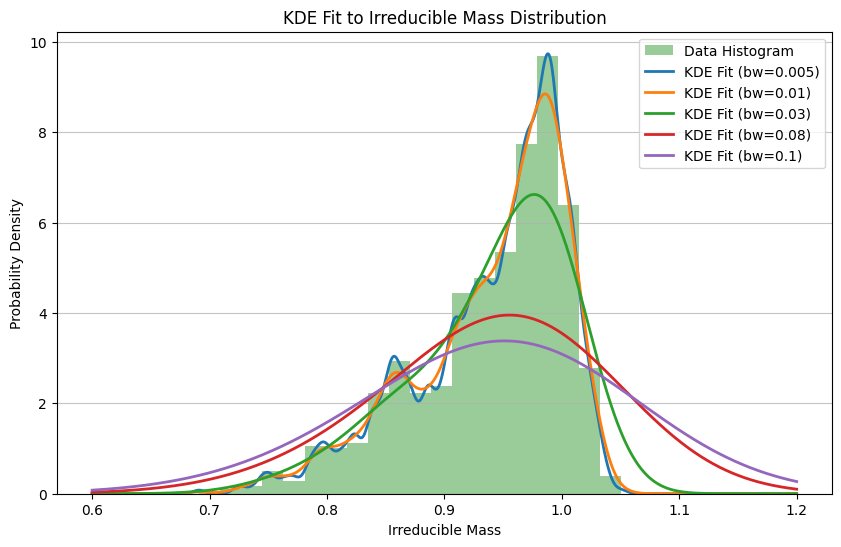

In [35]:
#Kernel Density Estimation for different bandwidht

bandwidths = [0.005, 0.01, 0.03, 0.08, 0.1] 
x = np.linspace(0.6, 1.2, 1000).reshape(-1, 1)

plt.figure(figsize=(10, 6))

# Histo plot
plt.hist(M_irr, bins=20, density=True, alpha=0.4,
         color='green', label='Data Histogram')

# compute KDE
for bw in bandwidths:
    kde = KernelDensity(kernel='gaussian', bandwidth=bw).fit(M_irr.reshape(-1, 1))
    pdf = np.exp(kde.score_samples(x))
    plt.plot(x, pdf, lw=2, label=f'KDE Fit (bw={bw})')

plt.xlabel('Irreducible Mass')
plt.ylabel('Probability Density')
plt.title('KDE Fit to Irreducible Mass Distribution')
plt.grid(axis='y', alpha=0.75)
plt.legend()
plt.show()

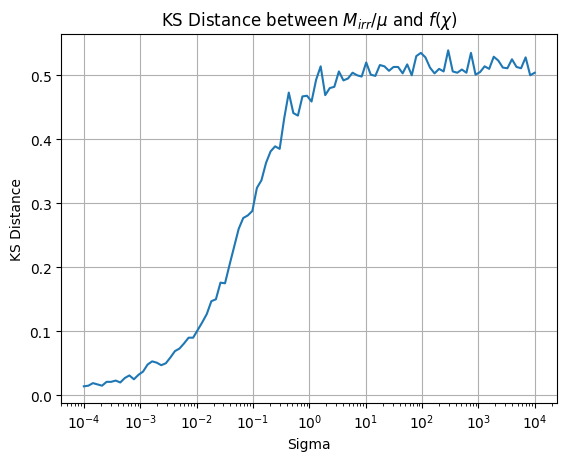

In [46]:
#compute the KS distance between the M_irr/mu and f(spin) as function of sigma 
sigmas = np.logspace(-4, 4, 100)

ks_distances = []
for sigma in sigmas:
    mass_distribution = np.random.normal(mu, sigma, N)
    M_irr = mass_distribution * f_spin
    
    ks_distance = scip.stats.ks_2samp(M_irr/mu, f_spin)[0]
    ks_distances.append(ks_distance)

plt.plot(sigmas, ks_distances)
plt.xlabel('Sigma')
plt.xscale ('log')
plt.ylabel('KS Distance')
plt.title('KS Distance between $M_{irr}$/$\mu$ and $f(\chi)$')
plt.grid()
plt.show()

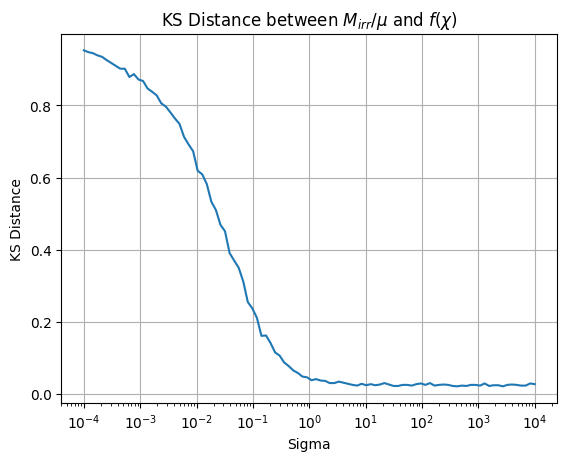

In [47]:
#compute the KS distance between the M_irr and M as function of sigma 

ks_distances = []
for sigma in sigmas:
    mass_distribution = np.random.normal(mu, sigma, N)
    M_irr = mass_distribution * f_spin
    
    ks_distance = scip.stats.ks_2samp(M_irr, mass_distribution)[0]
    ks_distances.append(ks_distance)

plt.plot(sigmas, ks_distances)
plt.xlabel('Sigma')
plt.xscale ('log')
plt.ylabel('KS Distance')
plt.title('KS Distance between $M_{irr}$/$\mu$ and $f(\chi)$')
plt.grid()
plt.show()